---

## Step-by-Step Explanation of Multinomial Logit (MNL) Model

1. **Dataset Preparation**
   - Start with a dataset containing observations of individuals/entities making choices among multiple alternatives, including characteristics of the alternatives and the chosen alternative.

2. **Utility Function**
   - Assume a utility function representing the preferences of individuals for each alternative.
   - Utility is a combination of alternative-specific variables (ASV) and generic variables (GV).
   - ASVs capture characteristics specific to each alternative (e.g., cost, time, availability).
   - GVs represent characteristics common across all alternatives (e.g., age, gender, income).

3. **Utility Equation**
   - Express the utility of each alternative using a linear equation.
   - The utility equation for alternative j is:
     $U_{ij} = \beta_{0j} + \beta_{1j}X_{1ij} + \beta_{2j}X_{2ij} + \ldots + \beta_{kj}X_{kij}$
     where i represents the individual, j represents the alternative, and $X_{ij}$ represents the values of the ASVs and GVs for individual i and alternative j.
   - The $\beta_{kj}$ coefficients represent the relative importance of each variable in determining the utility of alternative j.

4. **Choice Probability**
   - Calculate the choice probability for each alternative using the utility equation and a reference alternative (pivot).
   - Choose a reference alternative (e.g., alternative A) as the baseline for comparison.
   - The utility of the reference alternative is set to zero: U_{iA} = 0 for all individuals i.
   - The utility equation for alternative j (j ≠ A) is modified to be relative to the reference alternative:
     $U_{ij} - U_{iA} = \beta_{0j} + \beta_{1j}X_{1ij} + \beta_{2j}X_{2ij} + \ldots + \beta_{kj}X_{kij}$
   - The choice probability of alternative j for individual i is given by the softmax function:
     $P_{ij} = \frac{e^{(U_{ij} - U_{iA})}}{\sum_{m=1}^{M}e^{(U_{im} - U_{iA})}}$
     where M is the total number of alternatives.

5. **Log-Likelihood Function**
   - Construct the log-likelihood function to estimate the model parameters.
   - The log-likelihood function is:
     $LL(\beta) = \sum_{i=1}^{N} \sum_{j=1}^{M} \left( y_{ij} \cdot \ln(P_{ij}) \right)$
     where N is the total number of observations and $y_{ij}$ is an indicator variable that equals 1 if individual i chooses alternative j, and 0 otherwise.

6. **Maximum Likelihood Estimation (MLE)**
   - Estimate the model parameters by maximizing the log-likelihood function.
   - The MLE method finds the values of the $\beta_{kj}$ coefficients that maximize the likelihood of observing the choices made in the dataset.
   - The optimization process adjusts the $\beta_{kj}$ coefficients iteratively to find the best fit for the observed choices.

7. **Interpretation of Coefficients**
   - After estimating the model, interpret the coefficients to understand the impact of variables on the choice probabilities.
   - Since the reference alternative (e.g., alternative A) was used as the baseline, the estimated coefficients represent the differences in utility between each alternative and the reference alternative.
   - Positive coefficients indicate that an increase in the variable value increases the utility compared to the reference alternative, while negative coefficients indicate the opposite effect.
   - The magnitude of the coefficients reflects the strength of the influence of the corresponding variable on the choice probabilities.

8. **Predictions**
   - Use the estimated model to make predictions for new observations.
   - Calculate the choice probabilities for each alternative (relative to the reference alternative) and choose the alternative with the highest probability as the predicted choice.

The concept of a pivot or reference alternative allows us to compare the utilities and choice probabilities of different alternatives relative to a baseline. By setting the utility of the reference alternative to zero and expressing the utility equations and choice probabilities in relation to the reference alternative, we can estimate the differences in utility and understand the relative preferences for each alternative.

Note: In practice, the choice of the reference alternative is arbitrary and should be chosen based on domain knowledge or specific research objectives.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
df = pd.read_csv('data_incentive_attitudes.csv')
df

,Unnamed: 0,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,...,SEX,AGE,INCOME,recco,information,incentivezone,value,task,job_type,income_con
0,1,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,...,1,36,4,2,only enviro,0,1,1,company employee,9000000
1,2,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,...,1,36,4,2,only enviro,0,1,2,company employee,9000000
2,3,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,...,1,36,4,1,no info,0,1,3,company employee,9000000
3,4,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,...,1,36,4,1,no info,0,1,4,company employee,9000000
4,5,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,...,1,36,4,1,no info,0,1,5,company employee,9000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3081,3082,20248,116997,11/14/2020 14:50,11/14/2020 15:04,101,820,74.1,43.0,13.54,...,1,28,4,2,only enviro,0,1,24,company employee,9000000
3082,3083,20248,117147,11/14/2020 16:47,11/14/2020 17:23,101,410,40.5,74.4,23.67,...,1,28,4,2,only enviro,0,1,25,company employee,9000000
3083,3084,20248,116625,11/14/2020 9:27,11/14/2020 9:39,201,730,61.8,19.5,4.82,...,1,28,4,2,only enviro,0,1,26,company employee,9000000
3084,3085,20248,117772,11/15/2020 12:46,11/15/2020 13:16,998,550,46.2,74.2,24.06,...,1,28,4,4,only health,0,1,27,company employee,9000000


In [135]:
df = df.drop('Unnamed: 0', axis='columns')

In [136]:
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

In [138]:
# What is `recco`?

In [139]:
# Exogenous variables
basic_variables = list(df.columns)[:5]

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

alternative_specific_variables = list(df.columns)[5:29]
alternative_specific_variables.remove('mode')

attitudinal_variables = list(df.columns)[29:-10]
generic_variables = ['SEX', 'AGE', 'INCOME', 'job_type', 'information']

In [140]:
df.describe()

,user_id,trip_id,Purpose,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,...,PERS10,PERS11,SEX,AGE,INCOME,recco,incentivezone,value,task,income_con
count,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,...,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.0,3086.000000,3.086000e+03
mean,20116.454634,106605.627673,219.438756,20844.059624,20511.428192,137.599352,22.324407,9.996163,16782.832793,16492.947408,...,2.624433,2.496760,1.339922,43.575178,2.900518,2.498704,0.415424,1.0,16.724238,6.814971e+06
std,75.901662,5704.244578,214.574228,40176.964910,40345.109647,298.417107,19.597398,13.035629,36946.733549,37074.796717,...,0.898715,0.779699,0.473759,9.815280,1.442856,1.123997,0.492875,0.0,17.375072,2.995369e+06
min,20006.000000,96633.000000,100.000000,160.000000,13.600000,2.000000,0.620000,0.200000,100.000000,4.600000,...,1.000000,1.000000,1.000000,24.000000,1.000000,1.000000,0.000000,1.0,1.000000,3.000000e+06
25%,20039.000000,101707.500000,100.000000,320.000000,30.000000,29.500000,9.015000,2.950000,240.000000,28.800000,...,2.000000,2.000000,1.000000,36.000000,2.000000,1.000000,0.000000,1.0,6.000000,5.000000e+06
50%,20119.000000,106656.500000,101.000000,490.000000,42.400000,58.900000,17.540000,5.800000,370.000000,39.100000,...,2.000000,2.000000,1.000000,44.000000,3.000000,3.000000,0.000000,1.0,12.000000,7.000000e+06
75%,20181.000000,110734.500000,300.000000,947.500000,70.800000,129.200000,30.030000,12.530000,660.000000,59.700000,...,3.000000,3.000000,2.000000,51.000000,4.000000,4.000000,1.000000,1.0,21.000000,9.000000e+06
max,20248.000000,118320.000000,999.000000,99999.000000,99999.000000,3205.400000,181.900000,110.540000,99999.000000,99999.000000,...,5.000000,5.000000,2.000000,66.000000,7.000000,4.000000,1.000000,1.0,126.000000,1.700000e+07


# <ins><b>Data Preprocessing</b></ins>

## Feature Encoding

In [141]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [142]:
ohe = OneHotEncoder()

In [143]:
# one-hot encoding the job_type column
print(df['job_type'].value_counts())
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]

job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)
job_type_df.head()

company employee            1975
Part time job                401
civil servant                298
Self employed/ Freelance     146
Housewife                    127
Management executive          82
Unemployed                    40
Others                        17
Name: job_type, dtype: int64


,job_type_company employee,job_type_Part time job,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [144]:
# Keeping `INCOME` as oridnally encoded

In [145]:
# one-hot encoding the `information` column
print(df['information'].value_counts())
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])
info_df.head()

no info                   789
both enviro and health    780
only health               774
only enviro               743
Name: information, dtype: int64


,both enviro and health,no info,only enviro,only health
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [146]:
# one-hot encoding the SEX column
print(df['SEX'].value_counts())
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])
SEX_df.head()

1    2037
2    1049
Name: SEX, dtype: int64


,Male,Female
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


In [147]:
# one-hot encoding the purpose column
print(df['Purpose'].value_counts())

Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)
Purpose_df.head()

101    908
100    840
300    403
200    266
202    191
998    146
500    120
201    101
600     59
400     41
999     11
Name: Purpose, dtype: int64


,Purpose_101,Purpose_998,Purpose_100,Purpose_300,Purpose_200,Purpose_400,Purpose_600,Purpose_500,Purpose_202,Purpose_201,Purpose_999
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [148]:
def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 5:00) - 1
    Morning (5:00 to 12:00) - 2
    Afternoon (12:00 to 18:00) - 3
    Evening (18:00 to 00:00) - 4
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 5:
        return 1
    elif dep_hrs >= 5 and dep_hrs < 12:
        return 2
    elif dep_hrs >= 12 and dep_hrs < 18:
        return 3
    else:
        return 4

In [149]:
# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in 4 zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['early_morning_departure', 'morning_departure', 'afternoon_departure', 'evening_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)
dep_time_zones_df

,early_morning_departure,morning_departure,afternoon_departure,evening_departure
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
3081,0.0,0.0,1.0,0.0
3082,0.0,0.0,1.0,0.0
3083,0.0,1.0,0.0,0.0
3084,0.0,0.0,1.0,0.0


In [150]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')
df2.head()

,user_id,trip_id,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,...,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,both enviro and health,no info,only enviro,only health
0,20006,99545,770,69.4,151.7,43.72,15.17,240,60.9,182.04,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,20006,100663,690,66.2,128.6,38.96,12.86,240,44.9,154.32,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,20006,101712,770,69.4,151.7,43.72,15.17,240,60.9,182.04,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,20006,101878,500,56.2,118.5,29.53,11.85,400,59.0,142.20,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,20006,100936,770,69.4,151.7,43.72,15.17,240,60.9,182.04,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [151]:
# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'value', 'task', 'income_con'], axis='columns')

## Dealing with outliers

In [152]:
df3 = df2.copy()

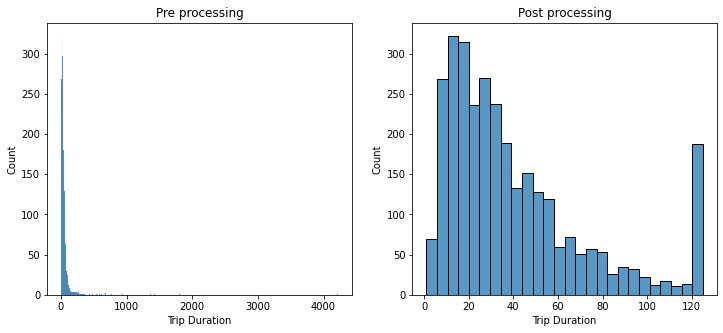

In [153]:
# Quantile based winsorization on trip duration
Q1 = df2['trip_duration'].quantile(0.25)
Q3 = df2['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 2*IQR
trip_durations = df2['trip_duration'].to_numpy()
trip_durations = np.where((trip_durations <= upper_bound), trip_durations, upper_bound)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(trip_durations, ax=ax[1])
sns.histplot(df2['trip_duration'], ax=ax[0])
ax[0].set_title('Pre processing')
ax[1].set_title('Post processing')
ax[1].set_xlabel('Trip Duration'); ax[0].set_xlabel('Trip Duration')

df3['trip_duration'] = trip_durations

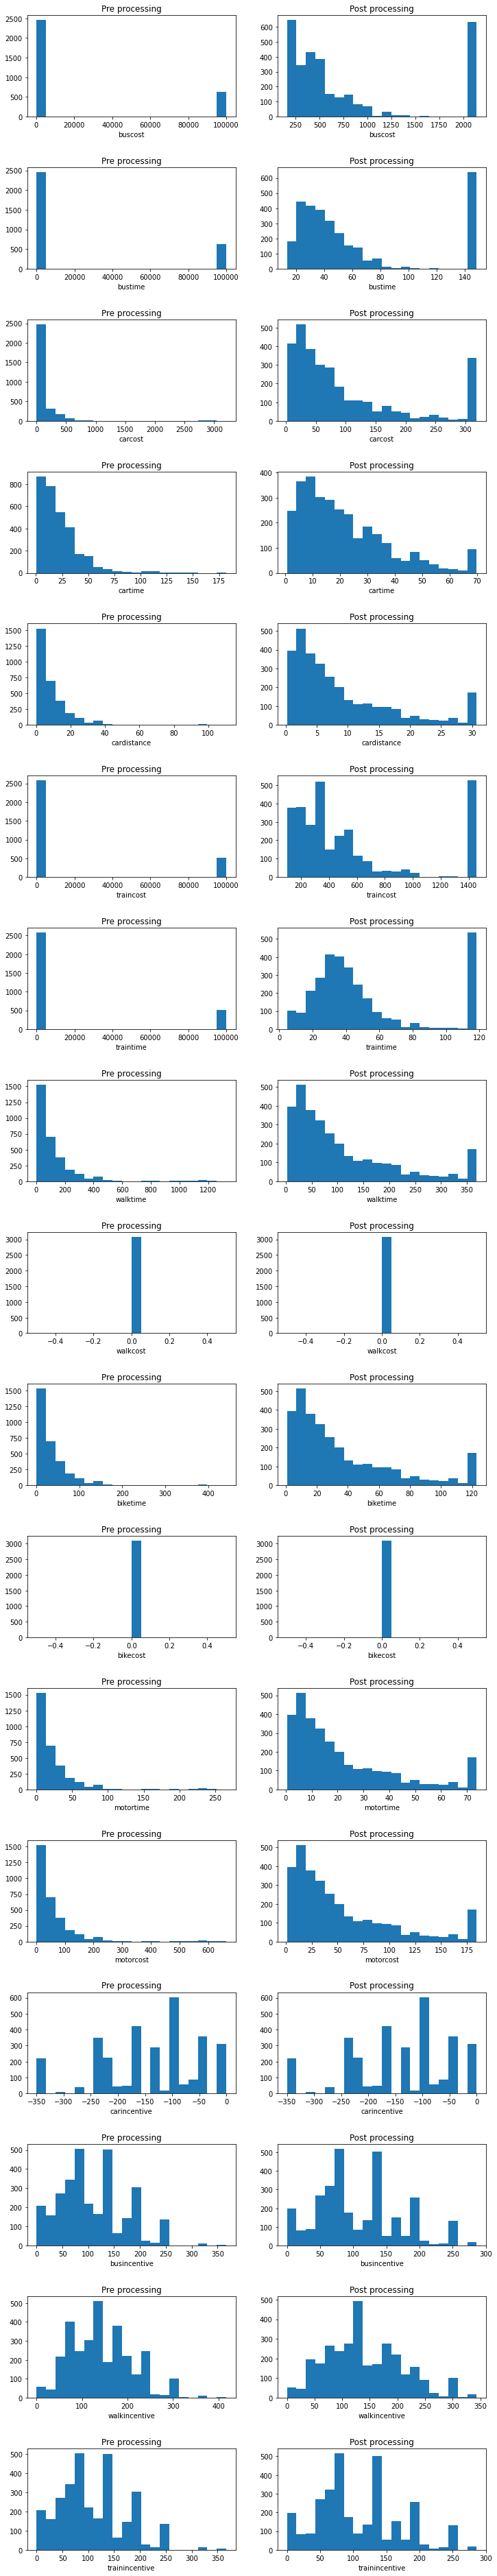

In [154]:
fig, ax = plt.subplots(len(alternative_specific_variables[:-6]), 2, 
                       figsize=(12, 4*len(alternative_specific_variables[:-6])), squeeze=False, gridspec_kw={'hspace':0.5})

for i in range(len(alternative_specific_variables[:-6])):
    Q1 = df2[alternative_specific_variables[i]].quantile(0.25)
    Q3 = df2[alternative_specific_variables[i]].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.9*IQR
    lower_bound = Q1 - 1.9*IQR
    asc_variable = df2[alternative_specific_variables[i]].to_numpy()
    df3[alternative_specific_variables[i]] = np.where((asc_variable <= upper_bound) & (asc_variable >= lower_bound), 
                                                      asc_variable, upper_bound)

    _ = ax[i, 1].hist(df3[alternative_specific_variables[i]], bins=20)
    _ = ax[i, 0].hist(df2[alternative_specific_variables[i]], bins=20)
    ax[i, 0].set_title('Pre processing')
    ax[i, 1].set_title('Post processing')
    ax[i, 1].set_xlabel(alternative_specific_variables[i])
    ax[i, 0].set_xlabel(alternative_specific_variables[i])

In [155]:
# Betting rid of bikecost and walkcost (no variability)
df3 = df3.drop(['bikecost', 'walkcost'], axis='columns')

In [165]:
continous_variables = ['buscost', 'bustime', 'carcost', 'cartime', 'cardistance', 
                       'traincost', 'traintime', 'walktime', 'biketime', 'motortime', 'motorcost', 
                       'carincentive', 'busincentive', 'walkincentive','trainincentive', 
                       'bikeincentive', 'motorincentive', 'AGE', 'trip_duration']
discrete_variables = list(set(df2.columns) - set(continous_variables))

## Train and Test Split

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
train_df, test_df = train_test_split(df3, test_size=0.2)
train_df.shape, test_df.shape

((2468, 122), (618, 122))

## Standardization

In [168]:
from sklearn.preprocessing import StandardScaler

In [169]:
ss = StandardScaler()
ss.fit(train_df[continous_variables])

StandardScaler()

In [170]:
train_df[continous_variables] = ss.transform(train_df[continous_variables])

In [171]:
train_df

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,biketime,motortime,...,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,both enviro and health,no info,only enviro,only health
2047,-0.870992,-0.951974,-0.788513,-0.959359,-0.818886,2.002703,1.961552,-0.818886,-0.818886,-0.818886,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2682,-0.898843,-0.714626,-0.908656,-1.087971,-0.961329,2.002703,1.961552,-0.961329,-0.961329,-0.961329,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2398,-0.634256,-0.729730,-0.679762,-0.693478,-0.689951,0.246018,-0.274059,-0.689951,-0.689951,-0.689951,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1450,0.117728,0.180825,-0.392868,-0.316297,-0.349808,-0.913217,-0.449149,-0.349808,-0.349808,-0.349808,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
393,0.117728,0.256345,0.663565,0.994559,0.902706,0.156846,0.134485,0.902706,0.902706,0.902706,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,1.858085,1.849168,-0.096653,-0.464078,0.001387,2.002703,1.961552,0.001387,0.001387,0.001387,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2642,-0.829215,-0.764253,-0.616584,-0.753456,-0.615046,-0.110670,-0.729294,-0.615046,-0.615046,-0.615046,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2006,-0.676033,-0.878612,-0.793692,-0.898763,-0.825026,0.134553,0.362102,-0.825026,-0.825026,-0.825026,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2742,-0.898843,-0.962763,-0.956299,-1.214729,-1.017815,0.803342,0.362102,-1.017815,-1.017815,-1.017815,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [172]:
train_df = train_df.drop(attitudinal_variables, axis='columns')
test_df = test_df.drop(attitudinal_variables, axis='columns')

In [173]:
selected_mode = train_df['mode'].to_numpy()
train_df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)
selected_mode = test_df['mode'].to_numpy()
test_df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)

# <ins><b>Model Formulation</b></ins>

In [175]:
import tensorflow as tf

In [176]:
categories = list(train_df['mode'].unique())
generic_variables = list(train_df.columns)[22:]
asc_variables = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walktime', 'walkincentive'],
    'bike': ['biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

In [177]:
# A paramters dictionary of dictionary, each dictionary consists of all the paramters corresponding to a particular mode
# As tensorflow variables with data as `[1]`

params = dict()

for mode_category in categories:
    params[mode_category] = dict()
    for asc_var in asc_variables[mode_category]:
        params[mode_category]['asc_'+asc_var] = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'asc_{asc_var}')
    params[mode_category][f'asc_{mode_category}_constant'] = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'asc_{mode_category}_constant')
    for gen_var in generic_variables:
        params[mode_category][f'gen_{mode_category}_{gen_var}'] = tf.Variable(tf.zeros([1,]), dtype=tf.float32, 
                                                                              name=f'gen_{mode_category}_{gen_var}')

In [198]:
def utility_func(df, params):
    """
    Returns the utility corresponding to each category, for a particular set of datapoints and paramters.
    """
    
    
    # Taking car as the refernce category
    utility_car = tf.zeros([df.shape[0], 1], name='utility_car')
    utilities = []
    
    for category in categories[1:]:
        asc_utility = params[category][f'asc_{category}_constant']
        # Adding the asc_variables*parameters
        for asc_var in asc_variables[category]:
            asc_utility = asc_utility + (params[category][f'asc_{asc_var}'] * df[asc_var])
        # Adding the generic_variables*paramters
        for gen_var in generic_variables:
            asc_utility = asc_utility + (params[category][f'gen_{category}_{gen_var}'] * df[gen_var])
            
        asc_utility = tf.reshape(asc_utility, shape=(-1, 1))
        asc_utility = tf.identity(asc_utility, name=f'utility_{category}')
        utilities.append(asc_utility)
    utility_train, utility_walk, utility_bike, utility_bus, utility_motor = utilities
    
    return utility_car, utility_train, utility_walk, utility_bike, utility_bus, utility_motor

In [199]:
utility_func(train_df, params)

(<tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>,
 <tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>,
 <tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>,
 <tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>,
 <tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>,
 <tf.Tensor: shape=(2468, 1), dtype=float32, numpy=
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], dtype=float32)>